In [1]:
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

from sklearn.metrics import silhouette_score

## Matrix creation

In [19]:
clust = 'gspy'
run = 'O3b'

arq_name = f'{clust}{run}'

In [23]:
repository = f'/home/esanches/Projetos/tSNE/Virgo/zrepository/{clust}/{run}/'
dt, perp = 2, 100

In [24]:
# Read the data
final_vecs = np.load(f'{repository}vecs_{arq_name}_dt{dt}.npy')
final_labs = np.load(f'{repository}labs_{arq_name}_dt{dt}.npy')

# Apply tSNE
tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=perp, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)
proj = tsne.fit_transform(final_vecs)

# Transform in dataFrame
proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])
labs_df = pd.DataFrame(final_labs, columns=['label'])

In [25]:
X_tsne = proj_df[["x axis", "y axis"]].values
y_labels = labs_df.values

In [26]:
X_tsne

array([[-15.383382 ,  15.584115 ],
       [ 20.367378 ,   0.3925794],
       [-45.25853  ,  -3.5575013],
       ...,
       [-28.950485 ,   3.7038586],
       [ -8.507651 ,  19.273796 ],
       [ 36.430637 ,   1.0452551]], shape=(7903, 2), dtype=float32)

In [27]:
y_labels

array([['Power_Line'],
       ['Extremely_Loud'],
       ['Whistle'],
       ...,
       ['Whistle'],
       ['Air_Compressor'],
       ['Extremely_Loud']], shape=(7903, 1), dtype=object)

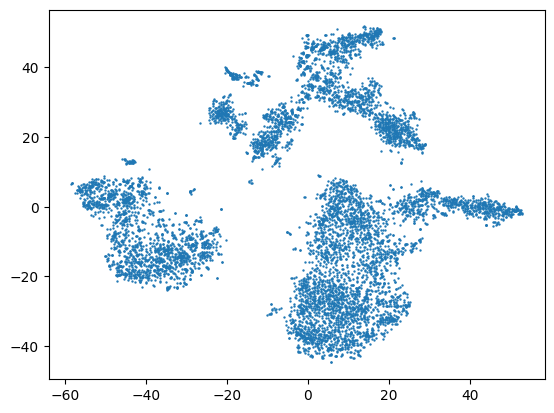

In [28]:
plt.scatter(*X_tsne.T, s=0.5)

## Classifier comparison

exemple from scijit-learn documentation

https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

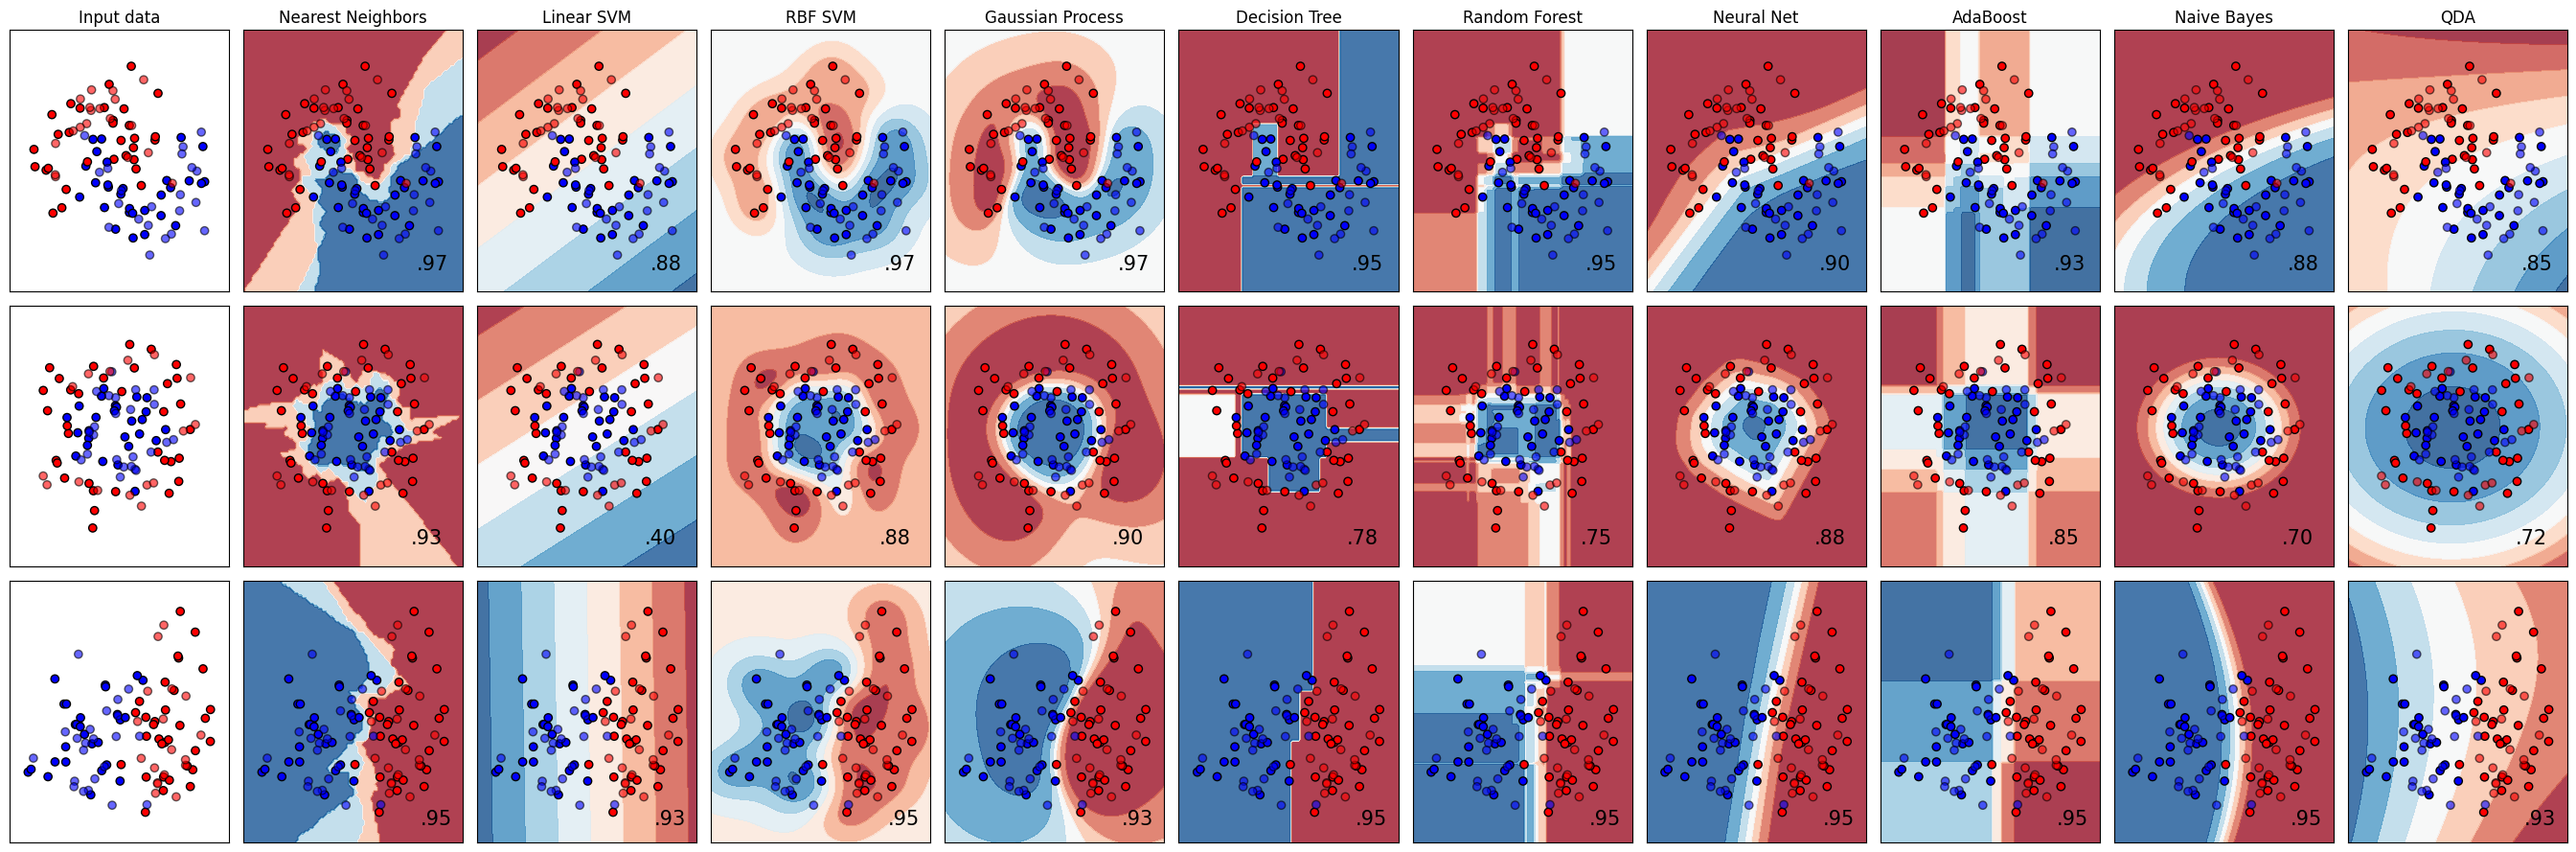

In [7]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]

figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

Try to applly in our data but take a while

In [38]:
from sklearn.preprocessing import LabelEncoder

# 1. Instancia o conversor de texto para número
le = LabelEncoder()

# 2. Transforma o seu y de texto em números sequenciais (0, 1, 2...)
# O .ravel() transforma o formato (4741, 1) em um formato plano (4741,)
y_numerico = le.fit_transform(y_labels.ravel())

# 3. Agora sim, alimente as variáveis do modelo:
X = X_tsne
y = y_numerico  # <--- Usando o array corrigido com números

In [ ]:
# ... [Mantenha todos os imports, as listas 'names' e 'classifiers' iguais] ...

# ==========================================
# 1. ENCAIXE SEUS DADOS AQUI
# ==========================================
# Substitua 'suas_labels_aqui' pela sua variável que contém as classes (ex: y, labels, etc.)
'''X = X_tsne
y = y_labels'''

# Divide seus dados em treino (60%) e teste (40%) para avaliar os modelos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Define os limites do gráfico baseados no seu X_tsne
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# ==========================================
# 2. ESTRUTURA DO GRÁFICO (Apenas 1 linha de subplots agora)
# ==========================================
# Agora teremos apenas 1 linha com: (quantidade de classificadores + 1 coluna para o dado bruto)
figure = plt.figure(figsize=(27, 4))
i = 1

# Colormap para o fundo e para os pontos
cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])

# Primeiro subplot: Plota apenas os seus dados originais (Input data)
ax = plt.subplot(1, len(classifiers) + 1, i)
ax.set_title("Input data")
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
ax.scatter(
    X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks(())
ax.set_yticks(())
i += 1

# ==========================================
# 3. LOOP PELOS CLASSIFICADORES
# ==========================================
for name, clf in zip(names, classifiers):
    ax = plt.subplot(1, len(classifiers) + 1, i)

    # Cria o pipeline, treina o modelo com seus dados e calcula o score
    clf = make_pipeline(StandardScaler(), clf)
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)

    # Desenha a fronteira de decisão na tela
    DecisionBoundaryDisplay.from_estimator(
        clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
    )

    # Plota os seus pontos por cima da fronteira
    ax.scatter(
        X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
    )
    ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        cmap=cm_bright,
        edgecolors="k",
        alpha=0.6,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(name)

    # Mostra a acurácia numérica no cantinho inferior direito de cada quadro
    ax.text(
        x_max - 0.3,
        y_min + 0.3,
        ("%.2f" % score).lstrip("0"),
        size=15,
        horizontalalignment="right",
    )
    i += 1

plt.tight_layout()
plt.show()

## HDBSCAN test from:

https://github.com/lmcinnes/hdbscan_paper/blob/master/Qualitative%20clustering%20results.ipynb

In [9]:
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from hdbscan import HDBSCAN
import seaborn as sns
from matplotlib import pyplot as plt

import zglitchfunc as gl 

%matplotlib inline
# sns.set_context('poster')

### How does it work?

In [33]:
data = np.load('clusterable_data.npy')
data

array([[-0.12153499, -0.22876337],
       [-0.22093687, -0.25251088],
       [ 0.1259037 , -0.27314321],
       ...,
       [ 0.50243143, -0.3002958 ],
       [ 0.53822256,  0.19412199],
       [-0.08688887, -0.2092721 ]], shape=(2309, 2))

In [34]:
kmeans_labels = KMeans(6).fit_predict(data)
dbscan_labels = DBSCAN(eps=0.025).fit_predict(data)
hdbscan_labels = HDBSCAN(min_cluster_size=15).fit_predict(data)

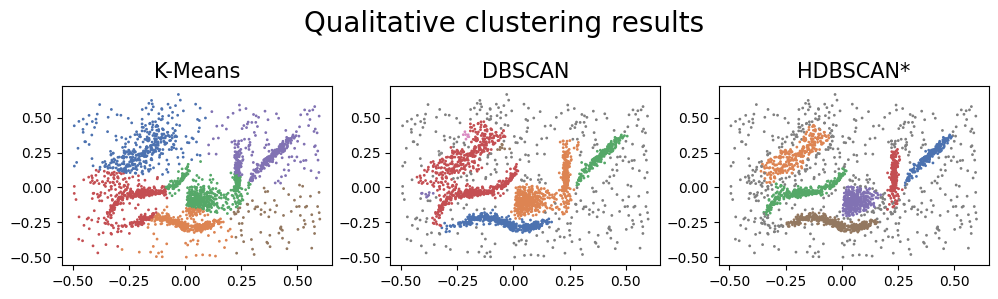

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
pal = sns.color_palette('deep', 10)

fig.suptitle('Qualitative clustering results', fontsize=20)


axs[0].scatter(*data.T, c=[pal[x] for x in kmeans_labels], s=1)
axs[0].set_title('K-Means', fontsize=15)

axs[1].scatter(*data.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in dbscan_labels], s=1)
axs[1].set_title('DBSCAN', fontsize=15)

axs[2].scatter(*data.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
axs[2].set_title('HDBSCAN*', fontsize=15)

plt.tight_layout()
plt.show()

The archetypal clustering algorithm, **K-Means**, suffers from all three of the problems mentioned previously: requiring the selection of the number of clusters; partitioning the data, and hence assigning noise to clusters; and the implicit assumption that clusters have Gaussian distributions. In comparison, being a density based approach, **DBSCAN** only suffers from the difficulty of parameter selection. Finally **HDBSCAN***resolves many of the difficulties in parameter selection by requiring only a small set of intuitive and fairly robust parameters.

Try to apply these in our matrix data

In [10]:
import random
import seaborn as sns

In [37]:
kmeans_labels = KMeans(10).fit_predict(X_tsne)
dbscan_labels = DBSCAN(eps=2, min_samples=5).fit_predict(X_tsne)
hdbscan_labels = HDBSCAN(min_cluster_size=100, min_samples=5, gen_min_span_tree=True).fit_predict(X_tsne)

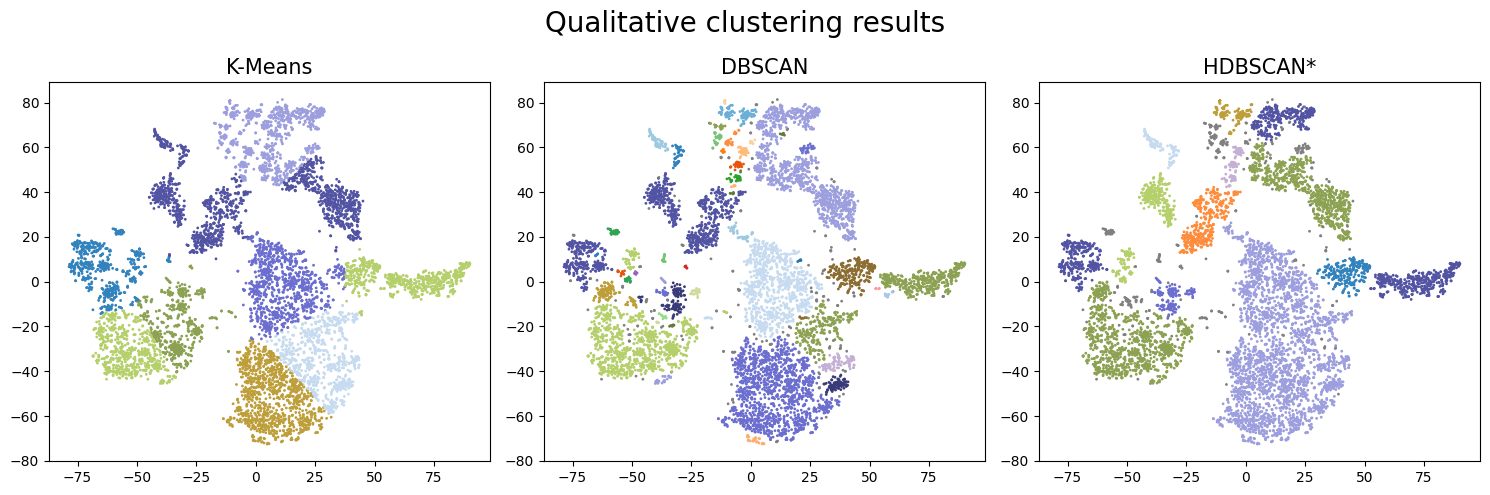

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

max_id_kmeans = max(kmeans_labels) if len(kmeans_labels) > 0 else 0
max_id_dbscan = max(dbscan_labels) if len(dbscan_labels) > 0 else 0
max_id_hdbscan = max(hdbscan_labels) if len(hdbscan_labels) > 0 else 0

num_clusters_total = max(max_id_kmeans, max_id_dbscan, max_id_hdbscan) + 1
cores_base = list(sns.color_palette("tab20", 10))
while len(cores_base) < num_clusters_total:
    cores_base.extend(sns.color_palette("tab20b", 10))
    cores_base.extend(sns.color_palette("tab20c", 10))
cores_base = cores_base[:num_clusters_total]
random.seed(42)
random.shuffle(cores_base)

pal = cores_base

fig.suptitle('Qualitative clustering results', fontsize=20)

axs[0].scatter(*X_tsne.T, c=[pal[x] for x in kmeans_labels], s=1)
axs[0].set_title('K-Means', fontsize=15)

axs[1].scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in dbscan_labels], s=1)
axs[1].set_title('DBSCAN', fontsize=15)

axs[2].scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
axs[2].set_title('HDBSCAN*', fontsize=15)

plt.tight_layout()
plt.show()

In [29]:
def colors(hdbscan_labels):
    max_id_hdbscan = max(hdbscan_labels) if len(hdbscan_labels) > 0 else 0
    cores_base = list(sns.color_palette("tab20", 10))
    while len(cores_base) < max_id_hdbscan + 1:
        cores_base.extend(sns.color_palette("tab20b", 10))
        cores_base.extend(sns.color_palette("tab20c", 10))
    cores_base = cores_base[:max_id_hdbscan + 1]
    random.seed(42)
    random.shuffle(cores_base)
    pal = cores_base

    return pal

## O3a Results

### HDBSCAN*

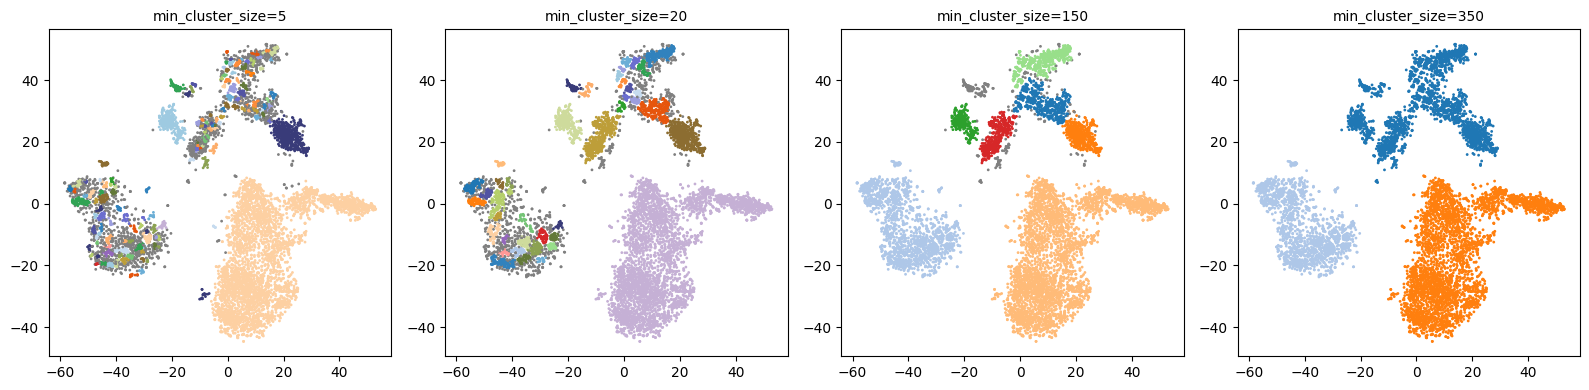

In [50]:
sizes = [5, 20, 150, 350]

fig, axs = plt.subplots(1, len(sizes), figsize=(len(sizes)*4, 4))

for i, s in enumerate(sizes):
    hdbscan_labels = HDBSCAN(min_cluster_size=s, min_samples=5, gen_min_span_tree=True).fit_predict(X_tsne)
    pal = colors(hdbscan_labels)

    axs[i].scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
    axs[i].set_title(f'min_cluster_size={s}', fontsize=10)

plt.tight_layout()
plt.show()

### Confusion matrix

In [43]:
mcs = 150

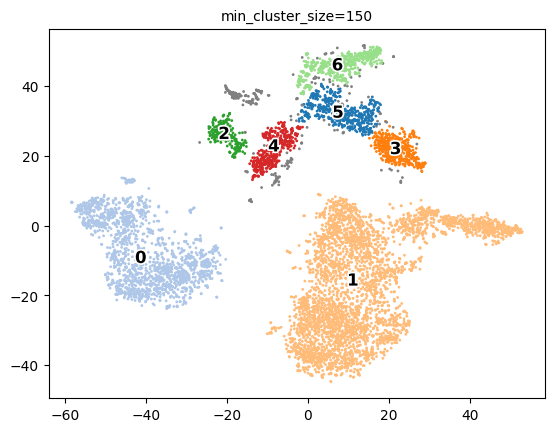

In [48]:
hdbscan_labels = HDBSCAN(min_cluster_size=mcs, min_samples=5, gen_min_span_tree=True).fit_predict(X_tsne)
pal = colors(hdbscan_labels)

plt.scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
plt.title(f'min_cluster_size={mcs}', fontsize=10)

for cluster_id in np.unique(hdbscan_labels):
    
    # Filtragem dos pontos que pertencem ao cluster atual
    cluster_mask = (hdbscan_labels == cluster_id)
    pontos_do_cluster = X_tsne[cluster_mask]
    
    # Calculamos o centro geométrico (mediana é mais robusta a outliers que a média)
    centro_x, centro_y = np.median(pontos_do_cluster, axis=0)
    
    # Define uma estilização diferente para o ruído (-1)
    if cluster_id == -1:
        continue
    else:
        texto = str(cluster_id)
        cor_texto = "black"
        peso = "bold"
        
    # Desenha o número no gráfico com uma "borda" (path_effects) branca para ficar legível
    txt = plt.text(centro_x, centro_y, texto, fontsize=12, 
                   fontweight=peso, color=cor_texto, ha='center', va='center')
    
    # Isso adiciona um contorno branco no texto para ele não sumir no meio dos pontos pretos/coloridos
    import matplotlib.patheffects as path_effects
    txt.set_path_effects([path_effects.withStroke(linewidth=2.5, foreground='w')])

plt.show()

In [45]:
final_vecs = np.load(f'{repository}vecs_{arq_name}_dt{dt}.npy')
final_labs = np.load(f'{repository}labs_{arq_name}_dt{dt}.npy')

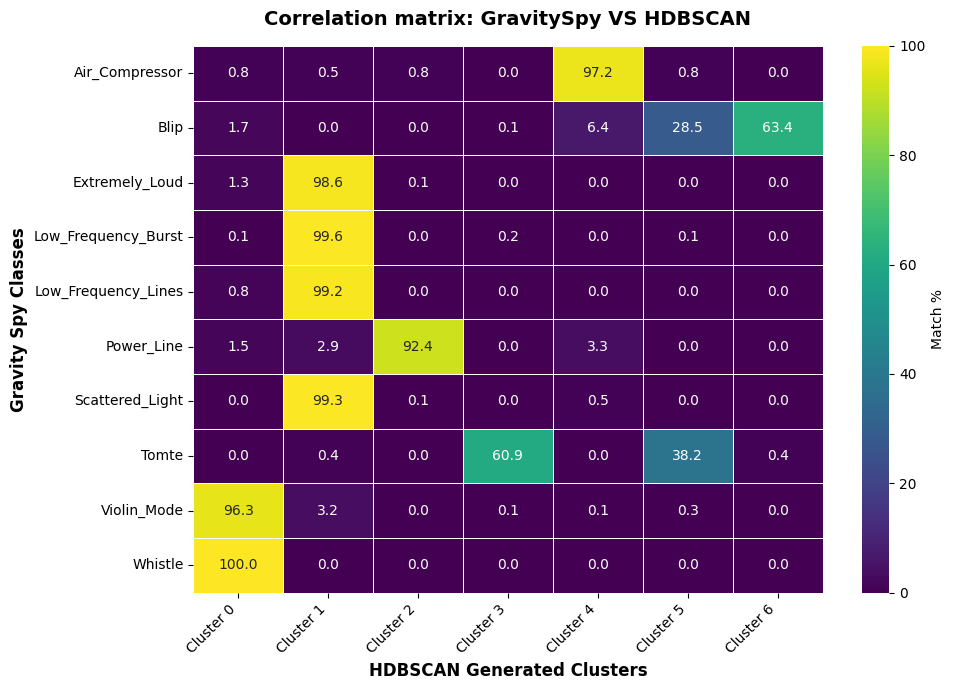

In [47]:
hdbscan_labels = HDBSCAN(min_cluster_size=150, min_samples=5).fit_predict(X_tsne)

df_comparacao = pd.DataFrame({'Gravity_Spy_Oficial': final_labs.ravel(), 'Cluster_HDBSCAN': hdbscan_labels})
df_comparacao['Cluster_HDBSCAN'] = df_comparacao['Cluster_HDBSCAN'].apply(lambda x: f'Cluster {x}' if x >= 0 else 'Ruído (-1)')
df_sem_ruido = df_comparacao[df_comparacao['Cluster_HDBSCAN'] != 'Ruído (-1)'].copy()

matriz_normalizada = pd.crosstab(df_sem_ruido['Gravity_Spy_Oficial'], df_sem_ruido['Cluster_HDBSCAN'], normalize='index') * 100

plt.figure(figsize=(10, 7))

sns.heatmap(matriz_normalizada, annot=True, cmap='viridis', fmt='.1f', linewidths=0.5, cbar_kws={'label': 'Match %'})

plt.title(f'Correlation matrix: GravitySpy VS HDBSCAN', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Gravity Spy Classes', fontsize=12, fontweight='bold')
plt.xlabel('HDBSCAN Generated Clusters', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right') # Rotaciona os nomes dos clusters para não encavalarem
plt.tight_layout()
plt.show()

### Silhouette score

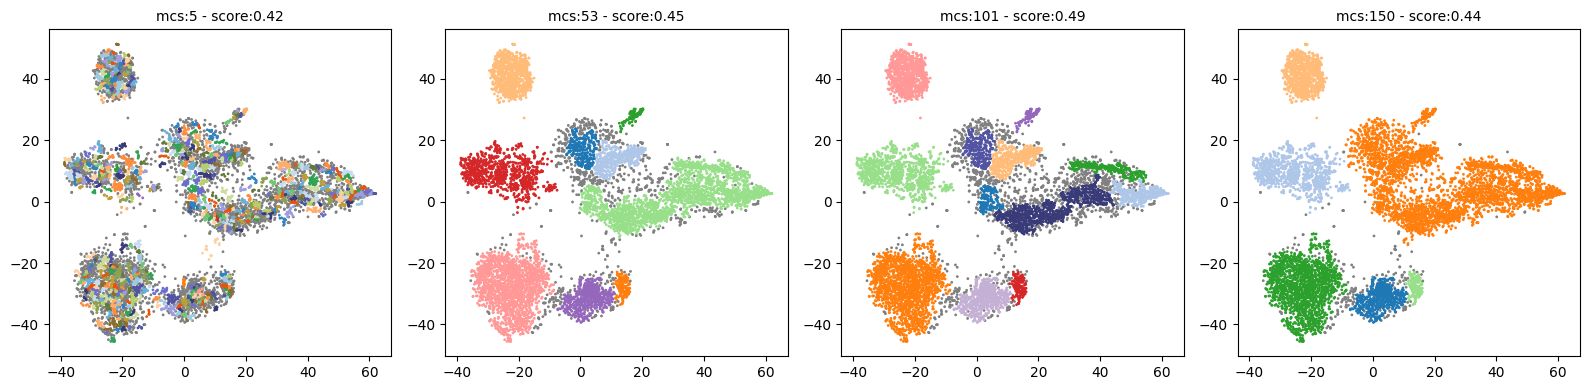

In [34]:
sizes = np.linspace(5, 150, num=4, dtype=int)

fig, axs = plt.subplots(1, len(sizes), figsize=(4*len(sizes), 4))
axs = axs.ravel()

silhouette_results = []

for i, s in enumerate(sizes):
    hdbscan_labels = HDBSCAN(min_cluster_size=s, min_samples=2, gen_min_span_tree=True).fit_predict(X_tsne)

    valid_mask = hdbscan_labels != -1
    unique_labels = np.unique(hdbscan_labels[valid_mask])

    if len(unique_labels) > 1:
        score = silhouette_score(X_tsne[valid_mask], hdbscan_labels[valid_mask])
        silhouette_results.append((s, score))
    else:
        silhouette_results.append((s, "N/A (Poucos clusters válidos)"))
    
    pal = colors(hdbscan_labels)
    axs[i].scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
    axs[i].set_title(f'mcs:{s} - score:{score:.2f}', fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
silhouette_results

[(np.int64(5), 0.4200704097747803),
 (np.int64(53), 0.44654735922813416),
 (np.int64(101), 0.48706865310668945),
 (np.int64(150), 0.44077056646347046)]

In [36]:
mcs, score = max(silhouette_results, key=lambda x: x[1])

In [37]:
score = max(silhouette_results, key=lambda x: x[1])[0]
print(f"Reexecutando para o melhor tamanho encontrado: {score}")

best_labels = HDBSCAN(min_cluster_size=mcs, min_samples=2, gen_min_span_tree=True).fit_predict(X_tsne)

df_completo = pd.DataFrame(X_tsne, columns=['tsne_coord_1', 'tsne_coord_2'])
df_completo['cluster'] = best_labels

dfs_por_cluster = {}

for cluster_id, grupo in df_completo.groupby('cluster'):
    dfs_por_cluster[cluster_id] = grupo.reset_index(drop=True)

print("\nQuantidade de pontos por DataFrame:")
for cid, df_grupo in dfs_por_cluster.items():
    nome = f"Cluster {cid}" if cid != -1 else "Ruído (-1)"
    print(f"{nome}: {len(df_grupo)} pontos")

Reexecutando para o melhor tamanho encontrado: 101

Quantidade de pontos por DataFrame:
Ruído (-1): 1085 pontos
Cluster 0: 743 pontos
Cluster 1: 1101 pontos
Cluster 2: 1653 pontos
Cluster 3: 109 pontos
Cluster 4: 556 pontos
Cluster 5: 185 pontos
Cluster 6: 341 pontos
Cluster 7: 448 pontos
Cluster 8: 334 pontos
Cluster 9: 225 pontos
Cluster 10: 386 pontos
Cluster 11: 955 pontos


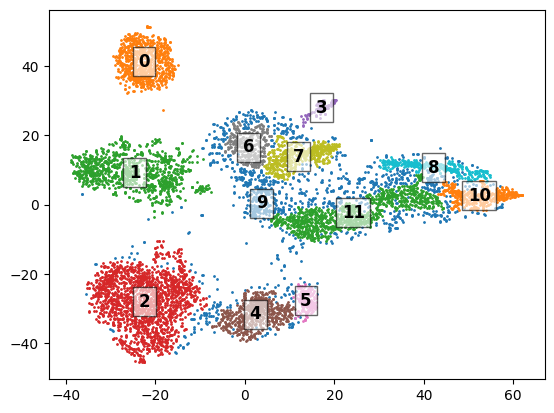

In [38]:
for key, df in dfs_por_cluster.items():
    plt.scatter(df['tsne_coord_1'], df['tsne_coord_2'], s=1)
    
    if key == -1:
            continue
    
    centro_x = df['tsne_coord_1'].mean()
    centro_y = df['tsne_coord_2'].mean()

    plt.text(centro_x, centro_y, str(key), fontsize=12, weight='bold', color='black', ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6))

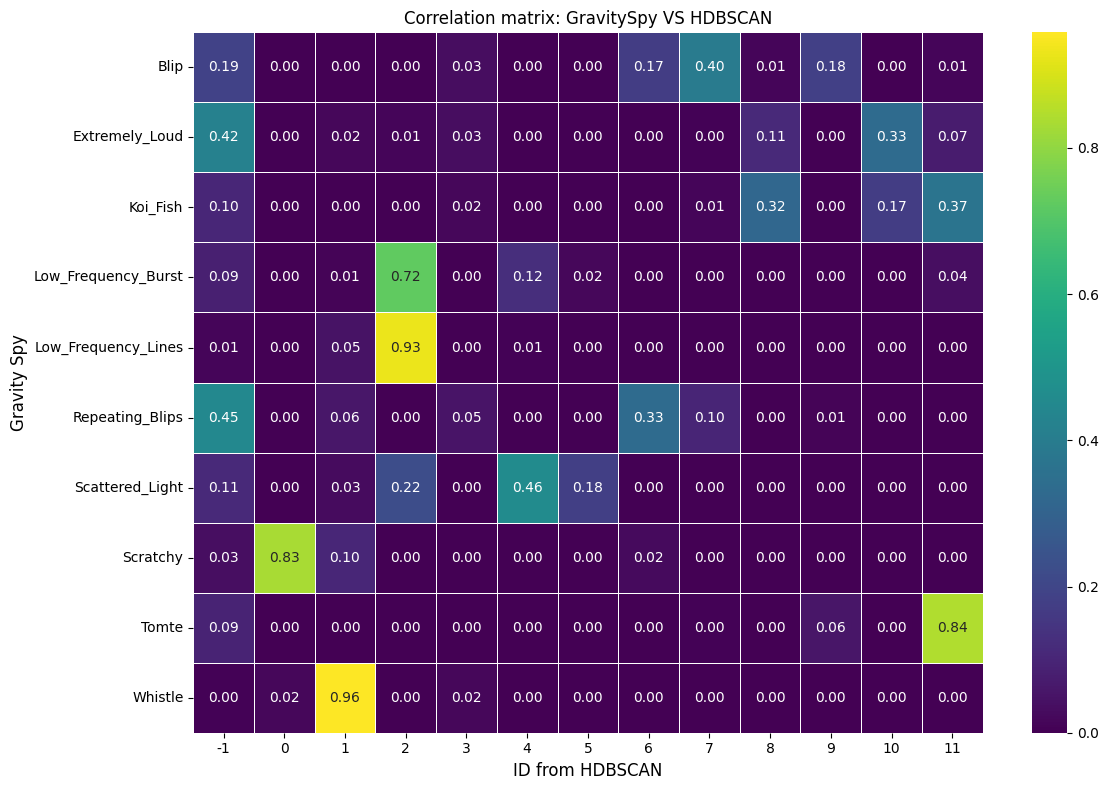

In [39]:
hdbscan_labels = HDBSCAN(min_cluster_size=mcs, min_samples=2, gen_min_span_tree=True).fit_predict(X_tsne)
#pal = colors(hdbscan_labels)

df_comparacao = pd.DataFrame({'Gravity_Spy_Oficial': final_labs, 'Cluster_HDBSCAN': hdbscan_labels})

matriz_contingencia = pd.crosstab(df_comparacao['Gravity_Spy_Oficial'], df_comparacao['Cluster_HDBSCAN'])

matriz_normalizada = pd.crosstab(df_comparacao['Gravity_Spy_Oficial'], df_comparacao['Cluster_HDBSCAN'], normalize='index') # Se preferir ver quantidade absoluta, remova essa linha)

plt.figure(figsize=(12, 8))

sns.heatmap(matriz_normalizada, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)

plt.title('Correlation matrix: GravitySpy VS HDBSCAN')
plt.ylabel('Gravity Spy', fontsize=12)
plt.xlabel('ID from HDBSCAN', fontsize=12)
plt.tight_layout()
plt.show()

### O3b results

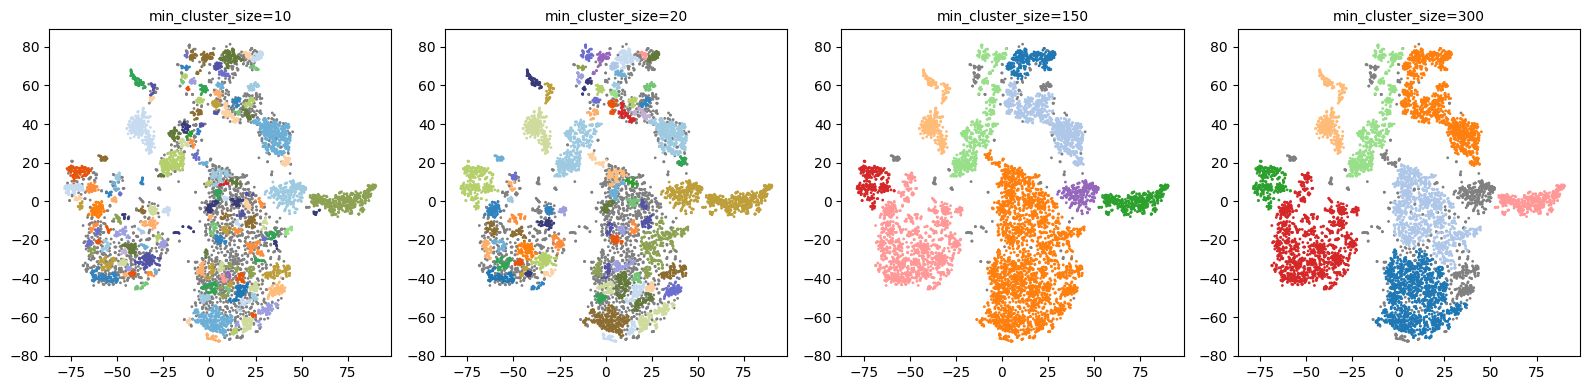

In [15]:
sizes = [10, 20, 150, 300]

fig, axs = plt.subplots(1, len(sizes), figsize=(len(sizes)*4, 4))

for i, s in enumerate(sizes):
    hdbscan_labels = HDBSCAN(min_cluster_size=s, min_samples=5, gen_min_span_tree=True).fit_predict(X_tsne)
    pal = colors(hdbscan_labels)

    axs[i].scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
    axs[i].set_title(f'min_cluster_size={s}', fontsize=10)

plt.tight_layout()
plt.show()

1 O3a - 2 O3b - 3 O3all

**LLS/Scattered Light** glitches separados dos demais pra analise de harmonicos

Consertar os GPStime dos dados **vecs X clustered**

**silhouette score** pra selecionar subclasses

matriz de confusão para validar numericamente **HDBSCAN x GravitySpy**

tSNE com dados filtrados por mês **(sazonalidade)**

### Choosing the points

In [41]:
xs, ys = [-20, -5, -5, -12], [25, 50, 75, 65]

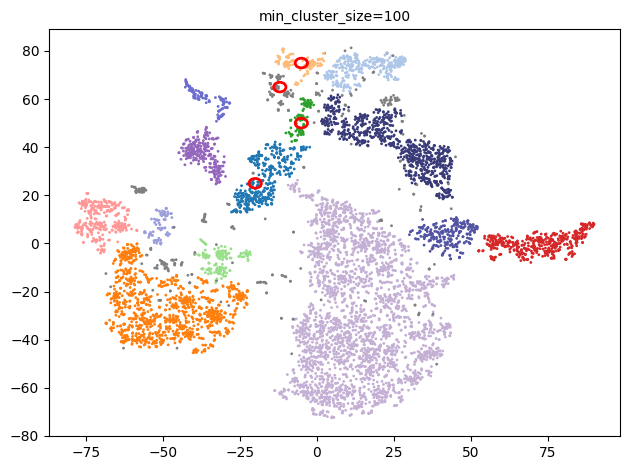

In [42]:
size = 100

hdbscan_labels = HDBSCAN(min_cluster_size=size, min_samples=5, gen_min_span_tree=True).fit_predict(X_tsne)
pal = colors(hdbscan_labels)

plt.scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
plt.title(f'min_cluster_size={size}', fontsize=10)

for x, y in zip(xs, ys):
    circulo = plt.Circle((x, y), 2, fill=False, edgecolor="red", lw=2)
    plt.gca().add_patch(circulo)

plt.tight_layout()
plt.show()

### read the data

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [44]:
# The percentage of triggers and glitches that you will use (float)
tperc, gperc = 0.7, 1.0

# The size of triggers and glitches data (int) ~ lenght
trigg_size, glit_size = 359385802, 187770

# The columns of triggers and glitches that you will use (str) ~ columns
trigcols = ['time', 'frequency', 'snr']
glitcols = ['GPStime', 'centralFreq', 'snr', 'label', 'confidence']

ntrig, nglit = int(trigg_size*tperc), int(glit_size*gperc)

# If this True, the clustered will be cut at 1000 glitches per label
filter1000 = True

In [45]:
readpath = '/home/esanches/Projetos/tSNE/Virgo/'

In [46]:
np.random.seed(42)
skip_logic = lambda i: i > 0 and np.random.random() > tperc
trigg = pd.read_csv(readpath + 'triggers_total.csv', skiprows=skip_logic, usecols=trigcols)
trigg = trigg.sort_values('time').reset_index(drop=True)

unclustered = trigg.copy()

In [47]:
unclustered.tail(5)

,time,frequency,snr
251583700,1.269672e+09,1426.656564,6.905275
251583701,1.269672e+09,474.735572,55.750837
251583702,1.269672e+09,1280.344030,8.660046
251583703,1.269672e+09,1079.892919,15.370766
251583704,1.269672e+09,879.323062,19.674751


In [48]:
glit = pd.read_csv(readpath + 'gspyO3b.csv', usecols=glitcols)
glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]
top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()
glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

if filter1000 == True:
    limited_glit = glit.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))

    limited_glit = limited_glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)
    clustered = limited_glit.copy()
else:
    clustered = glit.copy()

In [49]:
clustered.tail(5)

,GPStime,snr,centralFreq,confidence,label
8842,1.269588e+09,8.427,53.292,0.948,Air_Compressor
8843,1.269593e+09,2409.143,3983.241,1.000,Extremely_Loud
8844,1.269594e+09,36.901,3720.167,1.000,Whistle
8845,1.269595e+09,7.805,49.869,0.967,Air_Compressor
8846,1.269595e+09,128.902,3267.727,0.991,Extremely_Loud


### Find the GPStime of the glitchgram that we will see

In [54]:
from sklearn.preprocessing import LabelEncoder

In [55]:
final_labs = np.load(readpath + 'VecsRepository/all_o3b_run/labs_gspyb_filt_dt2.npy')
labs_df = pd.DataFrame(final_labs, columns=['label'])

cmap = plt.colormaps["tab10"]
le = LabelEncoder()
labels = le.fit_transform(labs_df.values.ravel())

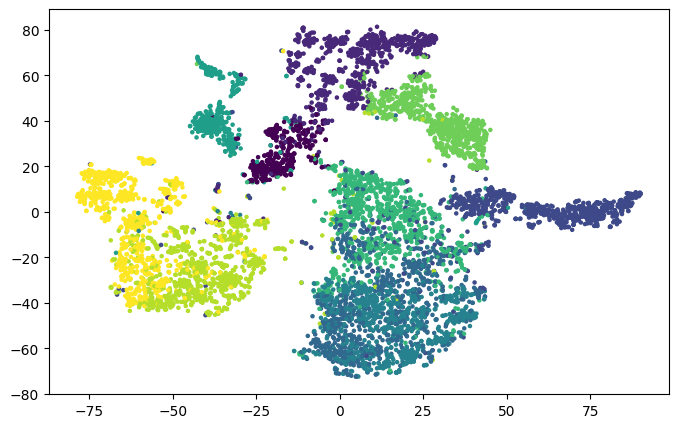

In [58]:
fig, ax = plt.subplots(figsize=(8,5))

sc = ax.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=labels,
    s=5,
    picker=True
)

In [60]:
def onpick(event):

    ind = event.ind[0]

    print("Índice:", ind)

    print(clustered.iloc[ind])

In [61]:
fig.canvas.mpl_connect('pick_event', onpick)

plt.show()

In [25]:
X_tsne

array([[-29.008123  ,  16.478365  ],
       [ 31.125305  ,   5.3796034 ],
       [-60.34638   , -14.816821  ],
       ...,
       [-36.008877  ,   8.931121  ],
       [-15.599795  ,  20.28603   ],
       [ 60.367462  ,  -0.32829836]], shape=(7903, 2), dtype=float32)

In [39]:
raio = 2

GPS_points = []

for x, y in zip(xs, ys):
    ponto_alvo = np.array([x, y])

    # Distância ao quadrado de todos os pontos
    dist2 = np.sum((X_tsne - ponto_alvo)**2, axis=1)

    # Índices dos pontos dentro do círculo
    indices = np.where(dist2 <= raio**2)[0]

    if len(indices) == 0:
        print(f"Nenhum ponto encontrado no círculo ({x}, {y})")
        GPS_points.append(None)
        continue

    # Labels dos pontos dentro do círculo
    labels = clustered.iloc[indices]["label"]

    # Label mais comum
    label_mais_comum = labels.value_counts().idxmax()

    print(f"Círculo ({x}, {y})")
    print(labels.value_counts())
    print(f"Label escolhido: {label_mais_comum}")

    # Pontos desse label
    indices_label = indices[labels == label_mais_comum]

    # Entre eles, pega o mais próximo do centro
    dist2_label = dist2[indices_label]
    indice_escolhido = indices_label[np.argmin(dist2_label)]

    gps = clustered.iloc[indice_escolhido]["GPStime"]

    GPS_points.append(gps)

print(GPS_points)

Círculo (-20, 25)
label
Power_Line             3
Extremely_Loud         2
Low_Frequency_Burst    2
Low_Frequency_Lines    1
Violin_Mode            1
Tomte                  1
Scattered_Light        1
Blip                   1
Whistle                1
Name: count, dtype: int64
Label escolhido: Power_Line
Círculo (-5, 50)
label
Low_Frequency_Lines    2
Blip                   1
Low_Frequency_Burst    1
Air_Compressor         1
Violin_Mode            1
Tomte                  1
Name: count, dtype: int64
Label escolhido: Low_Frequency_Lines
Círculo (-5, 75)
label
Blip              3
Extremely_Loud    1
Air_Compressor    1
Violin_Mode       1
Name: count, dtype: int64
Label escolhido: Blip
Círculo (-12, 65)
label
Low_Frequency_Burst    5
Tomte                  3
Blip                   3
Scattered_Light        2
Low_Frequency_Lines    2
Air_Compressor         1
Extremely_Loud         1
Whistle                1
Power_Line             1
Name: count, dtype: int64
Label escolhido: Low_Frequency_Burs

In [44]:
print(len(final_labs))
print(len(clustered))

7903
8847


In [29]:
GPS_points = []

for x, y in zip(xs, ys):
    ponto_alvo = np.array([x, y])

    distancias_ao_quadrado = np.sum((X_tsne - ponto_alvo) ** 2, axis=1)
    i_proximo = np.argmin(distancias_ao_quadrado)

    print(i_proximo)
    print(clustered.iloc[i_proximo]["label"])

    gps_do_ponto = clustered.iloc[i_proximo]["GPStime"]
    
    GPS_points.append(gps_do_ponto)
GPS_points

3687
Power_Line
2699
Low_Frequency_Burst
3935
Blip
3483
Low_Frequency_Lines


[np.float64(1261186168.172),
 np.float64(1259432080.281),
 np.float64(1261641701.104),
 np.float64(1260892474.438)]

### Plot the glitchgrams

Subplots of the glitchgrams

In [27]:
def plot_single_glitchgram_subplot(ax, unclustered, clustered, target_gps, deltat, fmin=3, fmax=8192, tbins=41, fbins=30):

    idx_closest = (clustered["GPStime"] - target_gps).abs().idxmin()
    row = clustered.loc[idx_closest]
    t_center = row["GPStime"]
    label_glitch = row["label"]

    times_all = unclustered["time"].values
    freqs_all = unclustered["frequency"].values
    snrs_all = unclustered["snr"].values

    tmin = t_center - deltat / 2
    tmax = t_center + deltat / 2

    time_edges = np.linspace(-deltat / 2, deltat / 2, tbins + 1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), fbins + 1)

    i0 = np.searchsorted(times_all, tmin, side="left")
    i1 = np.searchsorted(times_all, tmax, side="right")

    times = times_all[i0:i1] - t_center
    freqs = freqs_all[i0:i1]
    snrs = snrs_all[i0:i1]

    A = np.zeros((fbins, tbins), dtype=float)
    if len(times) > 0:
        t_idx = np.digitize(times, time_edges) - 1
        f_idx = np.digitize(freqs, freq_edges) - 1
        for ti, fi, si in zip(t_idx, f_idx, snrs):
            if 0 <= ti < tbins and 0 <= fi < fbins:
                if si > A[fi, ti]:
                    A[fi, ti] = si

    X_mesh, Y_mesh = np.meshgrid(time_edges, freq_edges)
    A_plot = np.where(A == 0, np.nan, A)

    # ATENÇÃO: Mudamos de plt.pcolormesh para ax.pcolormesh
    mesh = ax.pcolormesh(X_mesh, Y_mesh, A_plot, cmap="inferno", shading="flat")

    ax.set_yscale("log")
    ax.set_ylim(fmin, fmax)
    ax.set_xlim(-deltat / 2, deltat / 2)

    # Adiciona a barra de cores associada a este eixo específico
    cbar = plt.colorbar(mesh, ax=ax)
    cbar.set_label("SNR", fontsize=9)

    ax.set_title(f"GPS: {t_center}\nSpy: {label_glitch}", fontsize=10)
    ax.set_xlabel("Tempo [s]", fontsize=9)
    ax.set_ylabel("Frequência [Hz]", fontsize=9)
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

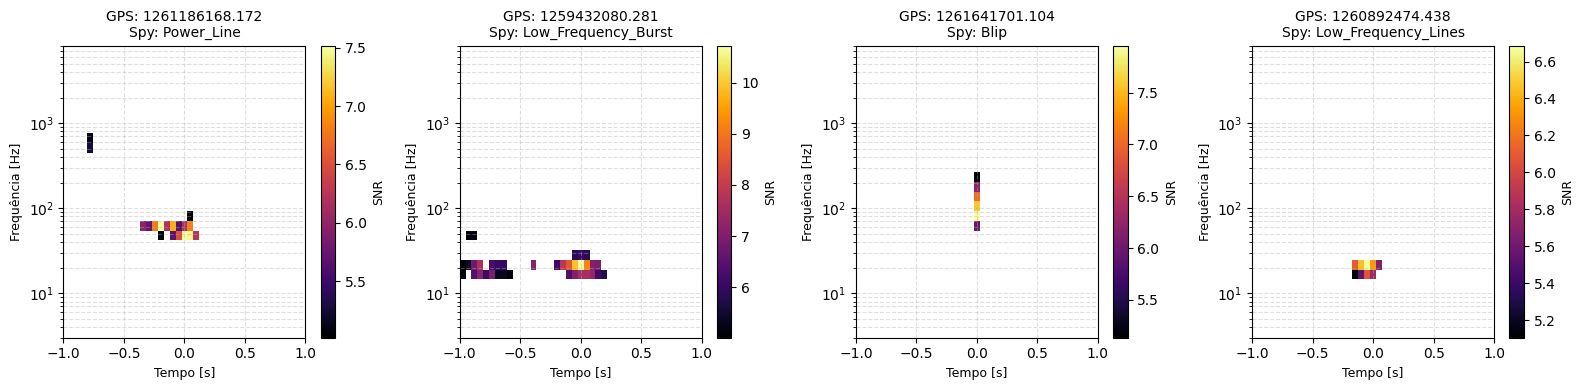

In [28]:
fig, axs = plt.subplots(1, len(GPS_points), figsize=(len(GPS_points)*4, 4))

axs = np.atleast_1d(axs)

for i, time in enumerate(GPS_points):

    plot_single_glitchgram_subplot(
        axs[i],  # Ele entra direto no parâmetro 'ax' da função
        unclustered,
        clustered,
        time,
        deltat=2,
        fmin=3,
        fmax=8192,
        tbins=41,
        fbins=30,
    )

plt.tight_layout()
plt.show()

### clusterização para toda O3a

In [82]:
glit = pd.read_csv(readpath + 'gspyO3b.csv', usecols=glitcols)
glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]
top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()
glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

if filter1000 == False:
    limited_glit = glit.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))

    limited_glit = limited_glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)
    clustered = limited_glit.copy()
else:
    clustered = glit.copy()

In [83]:
clustered.tail(5)

,GPStime,snr,centralFreq,confidence,label
118147,1.269606e+09,9.872,3983.241,0.996,Low_Frequency_Lines
118148,1.269606e+09,7.797,1563.095,0.982,Low_Frequency_Lines
118149,1.269608e+09,9.452,20.838,0.994,Low_Frequency_Lines
118150,1.269608e+09,9.131,30.952,0.993,Low_Frequency_Burst
118151,1.269609e+09,8.875,20.195,0.998,Low_Frequency_Lines


In [ ]:
sizes = [30, 50, 100, 150]

fig, axs = plt.subplots(1, len(sizes), figsize=(len(sizes)*4, 4))

for i, s in enumerate(sizes):
    hdbscan_labels = HDBSCAN(min_cluster_size=s, min_samples=5, gen_min_span_tree=True).fit_predict(X_tsne)
    pal = colors(hdbscan_labels)

    axs[i].scatter(*X_tsne.T, c=[pal[x] if x >= 0 else (0.5, 0.5, 0.5) for x in hdbscan_labels], s=1)
    axs[i].set_title(f'min_cluster_size={s}', fontsize=10)

plt.tight_layout()
plt.show()